# Notebook 03 — Modèles de Machine Learning

**Objectif** : Entraîner, comparer et optimiser différents modèles pour prédire le churn.

Ce notebook couvre :
- Modèles de régression (Régression Logistique, Ridge Classifier)
- Modèles de classification avancés (Arbre de Décision, Random Forest)
- Comparaison des modèles sur les métriques clés
- Optimisation des hyperparamètres avec GridSearchCV
- Visualisations : ROC, matrices de confusion, feature importance

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Chargement et split train/test

In [2]:
# On charge le dataset nettoyé
df = pd.read_csv("../data/processed/cleaned_telco.csv")

print("Taille du dataset :", df.shape)

Taille du dataset : (7043, 31)


In [3]:
# On sépare les features (X) de la cible (y)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Split 80% entraînement / 20% test
# stratify=y garantit la même proportion de churners dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape, "— Test :", X_test.shape)
print("Taux de churn train :", round(y_train.mean() * 100, 2), "%")
print("Taux de churn test  :", round(y_test.mean() * 100, 2), "%")

Train : (5634, 30) — Test : (1409, 30)
Taux de churn train : 26.54 %
Taux de churn test  : 26.54 %


## 2. Modèles de régression

On commence par des modèles linéaires, plus simples à interpréter.

### 2.1 Régression Logistique

**Pourquoi ?** C'est le modèle de référence pour la classification binaire.  
Simple, rapide, interprétable. Bon point de départ avant des modèles plus complexes.

In [4]:
# class_weight='balanced' compense le déséquilibre de classes (~26% churners)
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("=== Régression Logistique ===")
print(classification_report(y_test, y_pred_lr, target_names=["Non-Churn", "Churn"]))

=== Régression Logistique ===
              precision    recall  f1-score   support

   Non-Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### 2.2 Ridge Classifier (comparaison)

**Pourquoi ?** Variante linéaire avec régularisation L2.  
Permet de vérifier si la régression logistique est bien le meilleur modèle linéaire.

In [5]:
ridge = RidgeClassifier(class_weight="balanced")
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("=== Ridge Classifier ===")
print(classification_report(y_test, y_pred_ridge, target_names=["Non-Churn", "Churn"]))

=== Ridge Classifier ===
              precision    recall  f1-score   support

   Non-Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## 3. Modèles de classification avancés

### 3.1 Arbre de Décision

**Pourquoi ?** Très lisible et interprétable — on peut voir exactement les règles de décision.  
Utile pour expliquer les résultats à une équipe non technique.

In [6]:
dt = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("=== Arbre de Décision ===")
print(classification_report(y_test, y_pred_dt, target_names=["Non-Churn", "Churn"]))

=== Arbre de Décision ===
              precision    recall  f1-score   support

   Non-Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [7]:
# Interprétation des règles de décision
# On affiche les premières règles pour comprendre la logique du modèle
print("=== Règles de décision (profondeur 3) ===")
print(export_text(dt, feature_names=X.columns.tolist(), max_depth=3))

=== Règles de décision (profondeur 3) ===
|--- Contract_Two year <= 0.50
|   |--- Contract_One year <= 0.50
|   |   |--- InternetService_Fiber optic <= 0.50
|   |   |   |--- tenure <= -1.09
|   |   |   |   |--- class: 1
|   |   |   |--- tenure >  -1.09
|   |   |   |   |--- class: 0
|   |   |--- InternetService_Fiber optic >  0.50
|   |   |   |--- tenure <= -0.77
|   |   |   |   |--- class: 1
|   |   |   |--- tenure >  -0.77
|   |   |   |   |--- class: 1
|   |--- Contract_One year >  0.50
|   |   |--- StreamingMovies_Yes <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- class: 0
|   |   |--- StreamingMovies_Yes >  0.50
|   |   |   |--- MonthlyCharges <= 1.17
|   |   |   |   |--- class: 0
|   |   |   |--- MonthlyCharges >  1.17
|   |   |   |   |--- class: 0
|--- Contract_Two year >  0.50
|   |--- MonthlyCharges <= 1.28
|   |   |--- PaymentMethod_Electronic check <= 0.5

### 3.2 Random Forest

**Pourquoi ?** Combine plusieurs arbres de décision pour améliorer la précision  
et réduire le surapprentissage. Généralement plus performant qu'un seul arbre.

In [8]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["Non-Churn", "Churn"]))

=== Random Forest ===
              precision    recall  f1-score   support

   Non-Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## 4. Comparaison des modèles baseline

In [9]:
# On rassemble les métriques de tous les modèles dans un tableau
resultats = {}

modeles = {
    "Régression Logistique": (lr, y_pred_lr),
    "Ridge Classifier": (ridge, y_pred_ridge),
    "Arbre de Décision": (dt, y_pred_dt),
    "Random Forest": (rf, y_pred_rf),
}

for nom, (modele, y_pred) in modeles.items():
    # RidgeClassifier n'a pas predict_proba — on utilise decision_function pour l'AUC
    if hasattr(modele, "predict_proba"):
        auc_score = roc_auc_score(y_test, modele.predict_proba(X_test)[:, 1])
    else:
        auc_score = roc_auc_score(y_test, modele.decision_function(X_test))

    resultats[nom] = {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "AUC-ROC": round(auc_score, 4),
    }

df_resultats = pd.DataFrame(resultats).T
print(df_resultats.to_string())

                       Accuracy  Precision  Recall  F1-Score  AUC-ROC
Régression Logistique    0.7388     0.5052  0.7834    0.6143   0.8418
Ridge Classifier         0.7367     0.5026  0.7888    0.6139   0.8361
Arbre de Décision        0.7438     0.5113  0.7834    0.6188   0.8176
Random Forest            0.7899     0.6364  0.4866    0.5515   0.8246


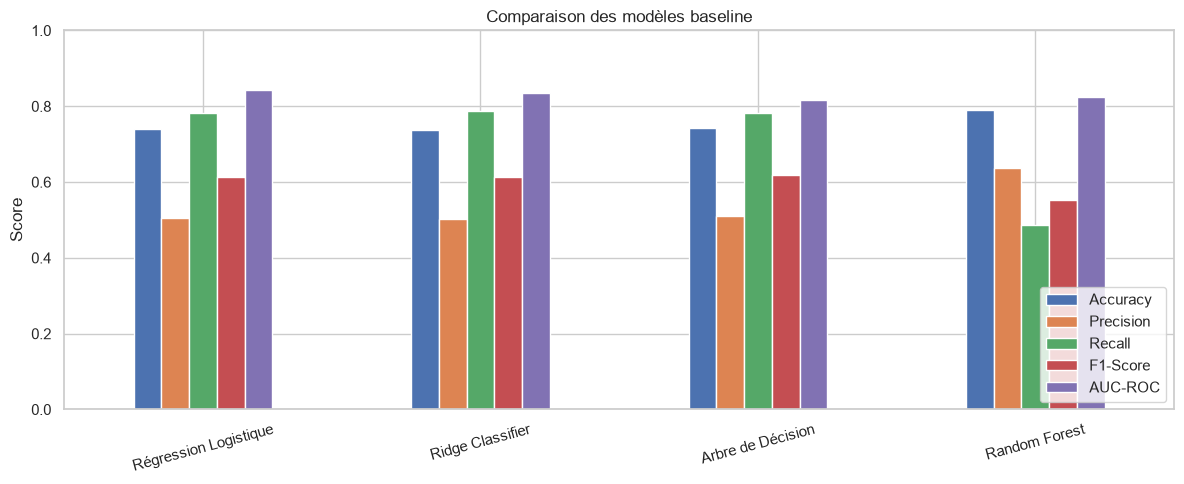

In [10]:
# Visualisation de la comparaison
df_resultats.plot(kind="bar", figsize=(12, 5), edgecolor="white")
plt.title("Comparaison des modèles baseline")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Optimisation avec GridSearchCV

On optimise le Random Forest — le plus performant des modèles baseline.  
On utilise une validation croisée stratifiée pour ne pas biaiser les résultats.

In [11]:
# Grille des hyperparamètres à tester
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

# StratifiedKFold garantit la proportion de churners dans chaque fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :")
print(grid_search.best_params_)
print("Meilleur score F1 (cross-validation) :", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Meilleurs hyperparamètres :
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score F1 (cross-validation) : 0.6341


In [12]:
# On récupère le meilleur modèle
rf_optimise = grid_search.best_estimator_

y_pred_rf_opt = rf_optimise.predict(X_test)

print("=== Random Forest Optimisé ===")
print(classification_report(y_test, y_pred_rf_opt, target_names=["Non-Churn", "Churn"]))

=== Random Forest Optimisé ===
              precision    recall  f1-score   support

   Non-Churn       0.89      0.78      0.83      1035
       Churn       0.54      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409



## 6. Visualisations avancées

### 6.1 Courbes ROC — Comparaison de tous les modèles

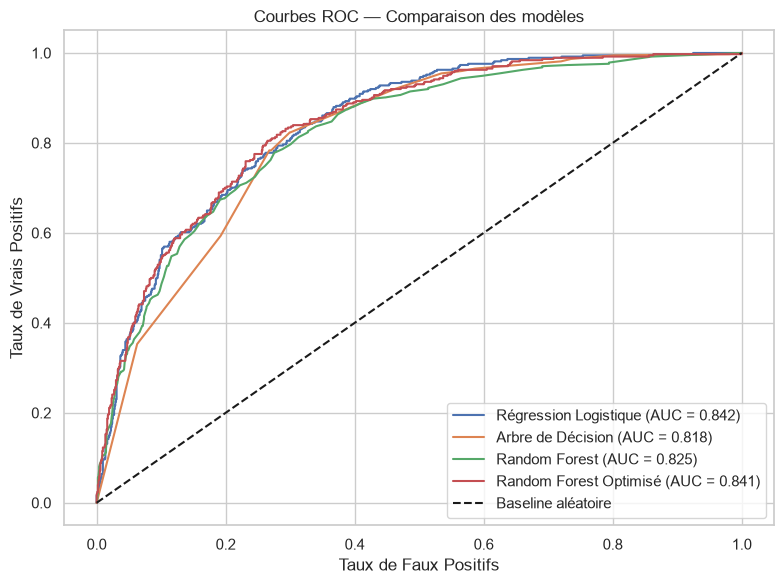

In [13]:
plt.figure(figsize=(8, 6))

# Modèles avec predict_proba
modeles_roc = {
    "Régression Logistique": lr,
    "Arbre de Décision": dt,
    "Random Forest": rf,
    "Random Forest Optimisé": rf_optimise,
}

for nom, modele in modeles_roc.items():
    y_prob = modele.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nom} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Baseline aléatoire")
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbes ROC — Comparaison des modèles")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.2 Matrices de confusion

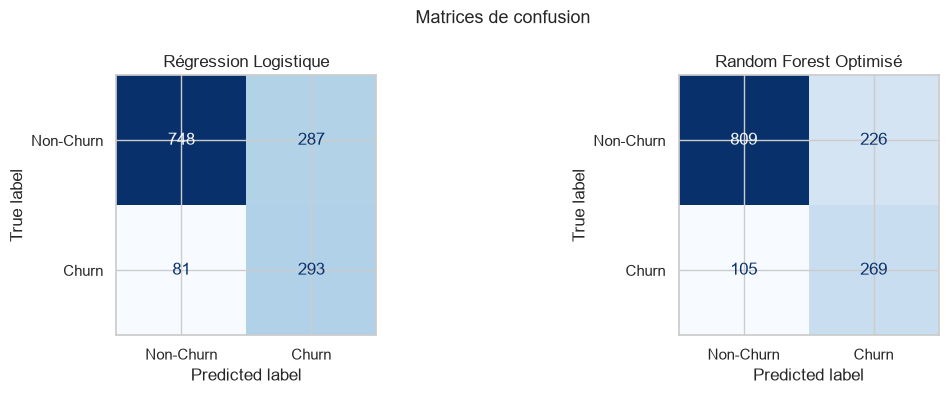

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Régression Logistique
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=["Non-Churn", "Churn"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Régression Logistique")

# Random Forest Optimisé
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf_opt),
    display_labels=["Non-Churn", "Churn"]
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Random Forest Optimisé")

plt.suptitle("Matrices de confusion", fontsize=13)
plt.tight_layout()
plt.show()

### 6.3 Importance des variables (Random Forest Optimisé)

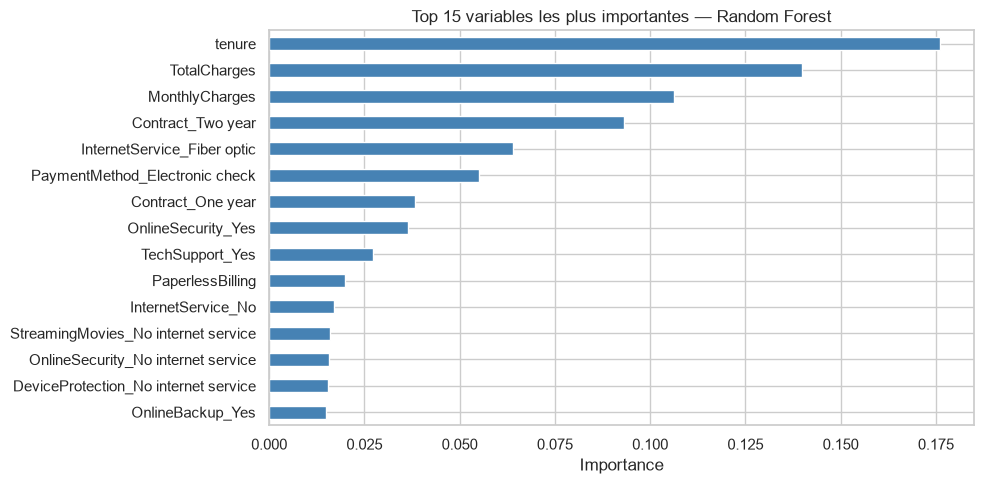

Top 5 variables :
tenure                         0.1762
TotalCharges                   0.1399
MonthlyCharges                 0.1064
Contract_Two year              0.0930
InternetService_Fiber optic    0.0641
dtype: float64


In [15]:
# On regarde quelles variables ont le plus influencé les prédictions
importances = pd.Series(
    rf_optimise.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# On affiche les 15 plus importantes
plt.figure(figsize=(10, 5))
importances.head(15).sort_values().plot(
    kind="barh", color="steelblue", edgecolor="white"
)
plt.title("Top 15 variables les plus importantes — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 variables :")
print(importances.head(5).round(4))

## Conclusion

**Résumé des performances :**

- La **Régression Logistique** est le meilleur modèle linéaire — bon rappel sur les churners
- Le **Ridge Classifier** est légèrement moins performant, confirmant que la LR est plus adaptée
- L'**Arbre de Décision** est interprétable mais moins précis que le Random Forest
- Le **Random Forest** (baseline et optimisé) obtient les meilleures performances globales

**Modèle retenu** : Random Forest Optimisé — meilleur compromis précision / rappel / AUC-ROC

**Variables les plus importantes** : tenure, MonthlyCharges, TotalCharges et le type de contrat

La validation finale sur le test set est réalisée dans le notebook 04.